In [15]:
import cv2,os
import numpy as np
import torch
import torchvision
from torchvision import models
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt

# from skimage.filters import gaussian

from shap_bpt_setup import *

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


dataset = datasets.Caltech101(
    root="./data",
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

HTTPError: HTTP Error 404: Not Found

In [16]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if ('mps' in dir(torch.backends)) and torch.backends.mps.is_available() else torch.device("cpu")
print(device)

cuda


In [17]:
import timm

model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)    # Resnet50_Weights 
# model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)    # Resnet50_Weights 
# model = torchvision.models.vit_b_16(weights='IMAGENET1K_V1')                     # vit_b_16_Weights    
# model = models.vgg16(pretrained=True)
# model = timm.create_model('vit_base_patch16_224', pretrained=True)
# model = timm.create_model('swin_base_patch4_window7_224', pretrained=True)

model = model.to('cuda').eval()

#########################################################
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
resnet50_preprocess = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(mean=mean, std=std)]
)

def f(x):
    return F.softmax(model(x), dim=1).cpu().detach().numpy()

In [18]:
import urllib.request
import json
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
with urllib.request.urlopen(url) as response:
    data = json.loads(response.read().decode())

class_names = [v[1] for v in data.values()]
print("Number of ImageNet classes:", len(class_names))


Number of ImageNet classes: 1000


In [19]:
def load_image(ds_path='D:/DS/ImageNet/ImageNet/ILSVRC2012_img_val//',fname='ILSVRC2012_val_00000774',bg_type=None):
    if os.path.isfile(f'{ds_path}/{fname}.JPEG')==False:
        raise ValueError(f'File {ds_path}/{fname}.JPEG does not exist!')
    image_to_explain         = cv2.resize(cv2.imread(f'{ds_path}/{fname}.JPEG', cv2.IMREAD_COLOR),[224,224])[:,:,::-1]
    image_to_explain_tensor  = resnet50_preprocess(image_to_explain.astype(np.float32)/255.0).to(device)
    np.random.seed(0)

    bkgnd0 = np.full_like(image_to_explain, 0)
    bkgnd1 = np.full_like(image_to_explain, 127)
    bkgnd2 = np.full_like(image_to_explain, 255)
    bkgnd3 = gaussian(image_to_explain, 8, channel_axis=-1)*255
    bkgnd4 = np.clip(np.random.normal(128, 128, size=image_to_explain.shape), 0, 255).astype(np.uint8)
    bkgnd4 = (gaussian(bkgnd4, 2.0, channel_axis=-1) * 255).astype(np.uint8)
    if bg_type=='black':
        background_image_set = np.array([bkgnd0])
    elif bg_type=='gray':
        background_image_set = np.array([bkgnd1])
    elif bg_type=='white':
        background_image_set = np.array([bkgnd2])
    elif bg_type=='blurred':
        background_image_set = np.array([bkgnd3])
    elif bg_type=='noise':
        background_image_set = np.array([bkgnd4])
    elif bg_type=='full':
        background_image_set = np.array([bkgnd0, bkgnd1, bkgnd2, bkgnd3, bkgnd4])

    background_image_preproc_set = [resnet50_preprocess(bkgnd.astype(np.float32)/255.0)
                                        for bkgnd in background_image_set]

    background_tensors = torch.cat([torch.unsqueeze(bk_p, dim=0) 
                                    for bk_p in background_image_preproc_set]).to(device)
    return image_to_explain,image_to_explain_tensor,background_image_set,background_tensors

image_to_explain,image_to_explain_tensor,background_image_set,background_tensors = load_image(fname='ILSVRC2012_val_00000774', bg_type='gray')

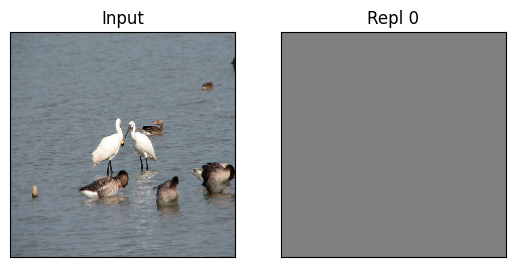

In [20]:
# image_to_explain,image_to_explain_tensor,background_image_set,background_tensors = load_image(fname='ILSVRC2012_val_00000774', bg_type='gray')

fig,ax = plt.subplots(1,1+len(background_image_set))
ax[0].imshow(image_to_explain); ax[0].set_title('Input'); ax[0].set_xticks([]); ax[0].set_yticks([])
for i,img in enumerate(background_image_set):
    ax[i+1].imshow(img.astype(np.uint8)); ax[i+1].set_title(f'Repl {i}'); ax[i+1].set_xticks([]); ax[i+1].set_yticks([])
plt.show()

In [21]:
def f_masked_resnet(masks):
    N,H,W = masks.shape
    B = background_tensors.shape[0]
    masks_tensor = torch.tensor(np.array(masks)).to(device)                     # N boolean masks with size W*H
    masks_tensor = torch.reshape(masks_tensor, (N,1,H,W))                       # N*H*W    -> N*1*H*W
    masks_tensor = torch.tile(masks_tensor, dims=(1,3,B,1)).reshape(B*N,3,H,W)  # N*1*H*W  -> NB*3*H*W
    Xf = torch.tile(image_to_explain_tensor, dims=(N*B,1,1,1))                  # 3*H*W    -> NB*3*H*W
    Xb = torch.tile(background_tensors, dims=(N,1,1,1))                         # 3*H*W    -> NB*3*H*W
    X = torch.where(masks_tensor, Xf, Xb) # T=Xf, F=Xb
    result = f(X)
    del X, Xb, Xf, masks_tensor
    result = result.reshape((-1, B, result.shape[1]))
    return np.mean(result, axis=1)

def f_masked(masks):
    return f_masked_resnet(masks)

In [22]:
def load_image_to_explain(fname=None,loaded_image = False, bg_type=None):
    image_to_explain,_,background_image_set,background_tensors = load_image(fname=fname,bg_type=bg_type)
    h,w,_ = image_to_explain.shape
    # Foreground image to be explained   
    predicted_fS = f(torch.unsqueeze(resnet50_preprocess(image_to_explain.astype(np.float32)/255.0).to(device), dim=0))[0]
    sorted_classes = np.flip(np.argsort(predicted_fS))
    predicted_cls = sorted_classes[0]
    f_S = float(predicted_fS[predicted_cls])
    #####################
    predicted_f0 = [f(torch.unsqueeze(resnet50_preprocess(bkgnd.astype(np.float32)/255.0).to(device), dim=0))[0] for bkgnd in background_image_set]
    predicted_f0 = np.mean(predicted_f0,axis=0)
    f_0          = float(predicted_f0[predicted_cls])
    return predicted_fS,predicted_cls, f_S, predicted_f0, f_0

In [23]:
predicted_fS,predicted_cls, f_S, predicted_f0, f_0 = load_image_to_explain(fname='ILSVRC2012_val_00000774' ,bg_type='gray')
print(class_names[predicted_cls],f_S,f_0)

pelican 0.2322997748851776 0.00023380275524687022


In [24]:
import shap_bpt
#---------------------------------------------------------------------
num_explained_classes = 4
batch_size = 4
num_samples = 1000
#---------------------------------------------------------------------
explainer = shap_bpt.Explainer(f_masked, image_to_explain, num_explained_classes=num_explained_classes, verbose=True)

In [25]:
shap_values_bpt = explainer.explain_instance(num_samples, method='BPT',batch_size=batch_size)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [26]:
shap_values_aa = explainer.explain_instance(num_samples, method='AA', batch_size=batch_size)

  0%|          | 0/1000 [00:00<?, ?it/s]

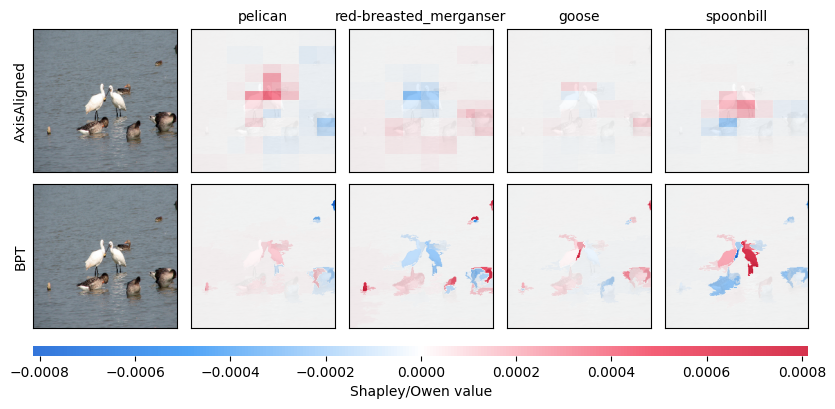

In [27]:
shap_bpt.plot_owen_values(explainer, [shap_values_aa,shap_values_bpt],class_names, names=['AxisAligned','BPT'])

In [28]:
# shap_bpt_tests.saliency_to_auc(f_masked, shap_values_bpt[0], f_S, f_0, predicted_cls, batch_size=4, method='del', num_samples=101, rule='trapezoid')
# heatmap, f_S, f_0, predicted_cls, batch_size=4, method='del', num_samples=101, rule='trapezoid'